<a href="https://colab.research.google.com/github/4321mona4321/logistic-regression-customer-prediction/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic Regression**



In [1]:
"""
Binary Logistic Regression Classifier Pipeline
Dataset: customer_purchase_data.csv
Target : PurchaseStatus (1 = Purchased, 0 = Did Not Purchase)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

RANDOM_STATE = 42

In [3]:
#load data
df = pd.read_csv("customer_purchase_data.csv")

TARGET = "PurchaseStatus"
NUMERIC_FEATURES = ["Age", "AnnualIncome", "NumberOfPurchases",
                     "TimeSpentOnWebsite", "DiscountsAvailed"]
CATEGORICAL_FEATURES = ["Gender", "ProductCategory", "LoyaltyProgram"]

In [11]:
#class distribution
print("=" * 60)
print(" Class Distribution")
print("=" * 60)
class_counts = df[TARGET].value_counts().sort_index()
class_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
dist_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct.round(2)
})
dist_table.index = ["Did Not Purchase (0)", "Purchased (1)"]
print(dist_table)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (majority:minority) = {imbalance_ratio:.2f} : 1")
if imbalance_ratio > 1.5:
    print("-> Meaningful imbalance detected; class_weight='balanced' is justified.")
else:
    print("-> Classes are reasonably balanced; class_weight='balanced' still applied per spec.")

 Class Distribution
                      Count  Percentage
Did Not Purchase (0)    852        56.8
Purchased (1)           648        43.2

Imbalance ratio (majority:minority) = 1.31 : 1
-> Classes are reasonably balanced; class_weight='balanced' still applied per spec.


In [10]:
#train and test
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("\n" + "=" * 60)
print(" Train/Test Split")
print("=" * 60)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True).round(3)}")


 Train/Test Split
Train shape: (1200, 8) | Test shape: (300, 8)
Train target distribution:
PurchaseStatus
0    0.568
1    0.432
Name: proportion, dtype: float64
Test target distribution:
PurchaseStatus
0    0.567
1    0.433
Name: proportion, dtype: float64


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

In [7]:
#model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced",
                                       random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'AnnualIncome',
                                                   'NumberOfPurchases',
                                                   'TimeSpentOnWebsite',
                                                   'DiscountsAvailed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'ProductCategory',
                                                   'LoyaltyProgram'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [9]:
#threshold evaluation
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_pred_proba >= 0.5).astype(int)

print("\n" + "=" * 60)
print(" Performance @ Default Threshold (0.5)")
print("=" * 60)
acc = accuracy_score(y_test, y_pred_default)
prec = precision_score(y_test, y_pred_default)
rec = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


 Performance @ Default Threshold (0.5)
Accuracy : 0.8367
Precision: 0.8000
Recall   : 0.8308
F1-Score : 0.8151
ROC-AUC  : 0.9000


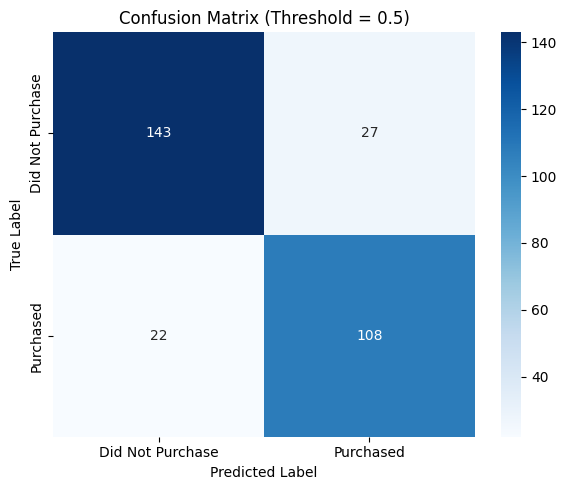


Saved: confusion_matrix.png


In [13]:
#confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did Not Purchase", "Purchased"],
            yticklabels=["Did Not Purchase", "Purchased"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("\nSaved: confusion_matrix.png")

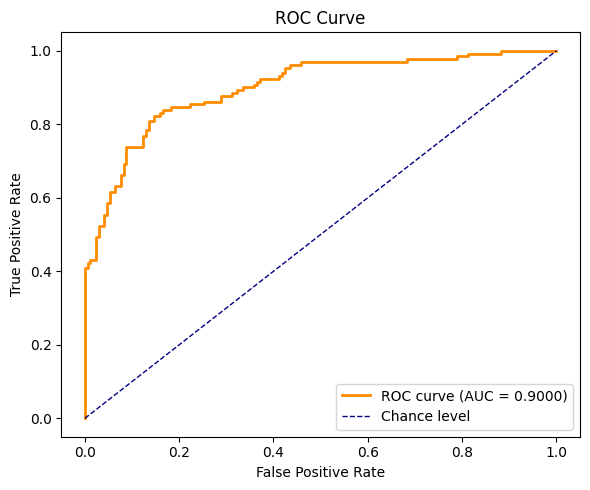

Saved: roc_curve.png


In [14]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Chance level")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
plt.close()
print("Saved: roc_curve.png")

In [19]:
print("\n" + "=" * 60)
print(" Threshold Sensitivity Analysis (0.2 - 0.8)")
print("=" * 60)

thresholds = np.round(np.arange(0.2, 0.85, 0.05), 2)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred_t), 4),
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

best_f1_row = threshold_df.loc[threshold_df["F1-Score"].idxmax()]
print(f"\nThreshold maximizing F1-Score: {best_f1_row['Threshold']} "
      f"(F1 = {best_f1_row['F1-Score']}, Precision = {best_f1_row['Precision']}, "
      f"Recall = {best_f1_row['Recall']})")


 Threshold Sensitivity Analysis (0.2 - 0.8)
 Threshold  Precision  Recall  F1-Score  Accuracy
      0.20     0.6029  0.9692    0.7434    0.7100
      0.25     0.6281  0.9615    0.7599    0.7367
      0.30     0.6383  0.9231    0.7547    0.7400
      0.35     0.6573  0.9000    0.7597    0.7533
      0.40     0.6805  0.8846    0.7692    0.7700
      0.45     0.7351  0.8538    0.7900    0.8033
      0.50     0.8000  0.8308    0.8151    0.8367
      0.55     0.8175  0.7923    0.8047    0.8333
      0.60     0.8636  0.7308    0.7917    0.8333
      0.65     0.8600  0.6615    0.7478    0.8067
      0.70     0.8889  0.6154    0.7273    0.8000
      0.75     0.8941  0.5846    0.7070    0.7900
      0.80     0.9403  0.4846    0.6396    0.7633

Threshold maximizing F1-Score: 0.5 (F1 = 0.8151, Precision = 0.8, Recall = 0.8308)


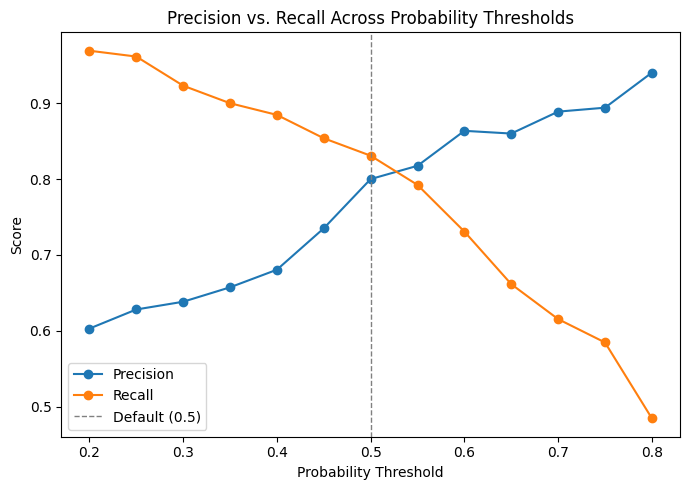

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.axvline(x=0.5, color="gray", linestyle="--", linewidth=1, label="Default (0.5)")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision vs. Recall Across Probability Thresholds")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()